## Environment Setup

In [38]:
# import relevant modules
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import imblearn

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Settings
pd.set_option('display.max_columns', None)
#np.set_printoptions(threshold=np.nan)
np.set_printoptions(precision=3)
sns.set(style="darkgrid")
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

print("pandas : {0}".format(pd.__version__))
print("numpy : {0}".format(np.__version__))
print("matplotlib : {0}".format(matplotlib.__version__))
print("seaborn : {0}".format(sns.__version__))
print("sklearn : {0}".format(sklearn.__version__))
print("imblearn : {0}".format(imblearn.__version__))

pandas : 2.2.2
numpy : 2.0.2
matplotlib : 3.10.0
seaborn : 0.13.2
sklearn : 1.6.1
imblearn : 0.14.1


## Load Data

In [39]:
# Load UNSW-NB15 training dataset
# The dataset is sorted by class, so we shuffle before sampling to get a representative subset
df_train_full = pd.read_csv('/content/UNSW_NB15_training-set.csv')   # update path as needed
df_test_full  = pd.read_csv('/content/UNSW_NB15_testing-set.csv')    # update path as needed

# Drop the 'id' column — not a feature
df_train_full.drop(['id'], axis=1, inplace=True)
df_test_full.drop(['id'], axis=1, inplace=True)

# Shuffle to ensure all classes are represented when we take a head() slice
df_train_full = df_train_full.sample(frac=1, random_state=42).reset_index(drop=True)
df_test_full  = df_test_full.sample(frac=1, random_state=42).reset_index(drop=True)


In [40]:
pd.DataFrame(df_train_full).head(10)


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,2.736664,tcp,-,FIN,232,438,13350,548216,244.458211,31,29,3.885899e+04,1.598925e+06,21,197,11.845558,6.261361,4449.110313,3234.831566,255,486483908,492604340,255,0.000558,0.000444,0.000114,58,1252,0,0,11,0,5,2,1,5,0,0,0,4,10,0,Normal,0
1,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,0,5.066666e+07,0.000000e+00,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,10,2,10,10,10,10,0,0,0,10,10,0,Generic,1
2,5.788526,tcp,-,FIN,36,34,6102,3892,11.920133,254,252,8.199669e+03,5.221364e+03,13,13,165.386453,172.345750,8561.040438,249.950547,255,3835852222,201002858,255,0.158826,0.057902,0.100924,170,114,0,0,4,1,2,1,1,4,0,0,0,2,4,0,Exploits,1
3,3.849634,tcp,-,FIN,448,858,25160,1094788,338.993271,31,29,5.216912e+04,2.272451e+06,38,390,8.669644,4.496707,4053.086020,2918.730804,255,2802824152,661443578,255,0.000558,0.000448,0.000110,56,1276,0,0,9,0,3,2,1,6,0,0,0,2,9,0,Normal,0
4,0.001052,udp,dns,CON,2,2,130,162,2851.711087,31,29,4.942966e+05,6.159696e+05,0,0,0.008000,0.007000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,65,81,0,0,3,0,4,1,1,1,0,0,0,3,3,0,Normal,0
5,0.000005,udp,dns,INT,2,0,114,0,200000.005100,254,0,9.120000e+07,0.000000e+00,0,0,0.005000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,34,2,25,25,12,34,0,0,0,25,34,0,Generic,1
6,0.000008,udp,dns,INT,2,0,114,0,125000.000300,254,0,5.700000e+07,0.000000e+00,0,0,0.008000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,9,2,9,9,9,9,0,0,0,9,9,0,Generic,1
7,1.465899,tcp,-,FIN,34,16,28660,814,33.426587,254,252,1.518140e+05,4.169455e+03,14,3,43.671909,91.675734,3963.321277,125.553867,255,3680557040,590273867,255,0.140336,0.090759,0.049577,843,51,0,0,6,1,1,1,1,4,0,0,0,2,4,0,Fuzzers,1
8,0.034137,tcp,smtp,FIN,52,42,37492,3380,2724.316772,31,29,8.617278e+06,7.733544e+05,18,8,0.689755,0.819268,42.179459,1.804168,255,4019493883,1875135451,255,0.000667,0.000542,0.000125,721,80,0,0,1,0,2,1,1,1,0,0,0,2,1,0,Normal,0
9,0.022733,tcp,-,FIN,48,50,2958,33044,4266.924890,31,29,1.019487e+06,1.139630e+07,7,18,0.477085,0.452469,25.926994,26.607684,255,2991578167,3016560789,255,0.000682,0.000559,0.000123,62,661,0,0,6,0,2,1,1,3,0,0,0,2,5,0,Normal,0


### Resizing Datasets

In [42]:
df_train = df_train_full.head(175341).copy()
df_train.shape


(175341, 44)

In [43]:
df_test = df_test_full.head(82332).copy()
df_test.shape


(82332, 44)

### Train dataset

In [44]:
print('Train set dimension: {} rows, {} columns'.format(df_train.shape[0], df_train.shape[1]))


Train set dimension: 175341 rows, 44 columns


In [45]:
pd.DataFrame(df_train).head(10)


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,2.736664,tcp,-,FIN,232,438,13350,548216,244.458211,31,29,3.885899e+04,1.598925e+06,21,197,11.845558,6.261361,4449.110313,3234.831566,255,486483908,492604340,255,0.000558,0.000444,0.000114,58,1252,0,0,11,0,5,2,1,5,0,0,0,4,10,0,Normal,0
1,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,0,5.066666e+07,0.000000e+00,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,10,2,10,10,10,10,0,0,0,10,10,0,Generic,1
2,5.788526,tcp,-,FIN,36,34,6102,3892,11.920133,254,252,8.199669e+03,5.221364e+03,13,13,165.386453,172.345750,8561.040438,249.950547,255,3835852222,201002858,255,0.158826,0.057902,0.100924,170,114,0,0,4,1,2,1,1,4,0,0,0,2,4,0,Exploits,1
3,3.849634,tcp,-,FIN,448,858,25160,1094788,338.993271,31,29,5.216912e+04,2.272451e+06,38,390,8.669644,4.496707,4053.086020,2918.730804,255,2802824152,661443578,255,0.000558,0.000448,0.000110,56,1276,0,0,9,0,3,2,1,6,0,0,0,2,9,0,Normal,0
4,0.001052,udp,dns,CON,2,2,130,162,2851.711087,31,29,4.942966e+05,6.159696e+05,0,0,0.008000,0.007000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,65,81,0,0,3,0,4,1,1,1,0,0,0,3,3,0,Normal,0
5,0.000005,udp,dns,INT,2,0,114,0,200000.005100,254,0,9.120000e+07,0.000000e+00,0,0,0.005000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,34,2,25,25,12,34,0,0,0,25,34,0,Generic,1
6,0.000008,udp,dns,INT,2,0,114,0,125000.000300,254,0,5.700000e+07,0.000000e+00,0,0,0.008000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,9,2,9,9,9,9,0,0,0,9,9,0,Generic,1
7,1.465899,tcp,-,FIN,34,16,28660,814,33.426587,254,252,1.518140e+05,4.169455e+03,14,3,43.671909,91.675734,3963.321277,125.553867,255,3680557040,590273867,255,0.140336,0.090759,0.049577,843,51,0,0,6,1,1,1,1,4,0,0,0,2,4,0,Fuzzers,1
8,0.034137,tcp,smtp,FIN,52,42,37492,3380,2724.316772,31,29,8.617278e+06,7.733544e+05,18,8,0.689755,0.819268,42.179459,1.804168,255,4019493883,1875135451,255,0.000667,0.000542,0.000125,721,80,0,0,1,0,2,1,1,1,0,0,0,2,1,0,Normal,0
9,0.022733,tcp,-,FIN,48,50,2958,33044,4266.924890,31,29,1.019487e+06,1.139630e+07,7,18,0.477085,0.452469,25.926994,26.607684,255,2991578167,3016560789,255,0.000682,0.000559,0.000123,62,661,0,0,6,0,2,1,1,3,0,0,0,2,5,0,Normal,0


### Test dataset

In [46]:
print('Test set dimension: {} rows, {} columns'.format(df_test.shape[0], df_test.shape[1]))


Test set dimension: 82332 rows, 44 columns


In [47]:
pd.DataFrame(df_test).head(10)


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1.292678,tcp,ftp,FIN,52,54,2934,3740,81.226725,31,29,1.781109e+04,22718.728520,11,15,25.340315,24.379660,2032.399964,67.804586,255,1861926481,1972779139,255,0.000703,0.000548,0.000155,56,69,0,0,1,0,5,1,1,4,1,1,0,7,1,0,Normal,0
1,0.000007,udp,dns,INT,2,0,114,0,142857.140900,254,0,6.514286e+07,0.000000,0,0,0.007000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,10,2,4,5,4,4,0,0,0,5,4,0,Generic,1
2,0.000010,udp,dns,INT,2,0,114,0,100000.002500,254,0,4.560000e+07,0.000000,0,0,0.010000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,51,2,23,23,13,51,0,0,0,23,51,0,Generic,1
3,0.000000,arp,-,INT,1,0,46,0,0.000000,0,0,0.000000e+00,0.000000,0,0,60000.752000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,46,0,0,0,1,2,1,1,1,1,0,0,0,1,1,1,Normal,0
4,0.189998,tcp,-,FIN,10,6,1460,268,78.948199,254,252,5.532690e+04,9431.677734,2,1,19.378444,36.389602,1025.975620,60.734199,255,190656160,3729297770,255,0.057777,0.008046,0.049731,146,45,0,0,1,1,1,1,1,1,0,0,0,1,1,0,Exploits,1
5,0.000008,udp,dns,INT,2,0,114,0,125000.000300,254,0,5.700000e+07,0.000000,0,0,0.008000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,24,2,18,18,18,24,0,0,0,19,24,0,Generic,1
6,0.018855,tcp,-,FIN,16,18,1540,1644,1750.198894,31,29,6.126757e+05,658923.375000,4,4,1.236200,1.077000,74.172985,2.182503,255,1379963200,1384679756,255,0.000676,0.000543,0.000133,96,91,0,0,7,0,7,6,1,6,0,0,0,9,11,0,Normal,0
7,0.558848,tcp,-,FIN,10,14,794,6798,41.156091,62,252,1.023534e+04,90371.617190,2,4,62.094222,38.441385,3779.376221,3149.359056,255,321857326,1523280552,255,0.121613,0.058328,0.063285,79,486,0,0,1,1,1,1,1,1,0,0,0,1,1,0,Exploits,1
8,2.020807,tcp,-,FIN,10,8,842,354,8.412481,254,252,3.000781e+03,1227.232422,2,1,224.534111,277.363156,14143.321500,402.606250,255,1316255462,3362912266,255,0.156175,0.077776,0.078399,84,44,0,0,1,1,1,1,1,1,0,0,0,1,2,0,Normal,0
9,0.000009,unas,-,INT,2,0,200,0,111111.107200,254,0,8.888889e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,100,0,0,0,7,2,3,3,3,7,0,0,0,3,7,0,Exploits,1


## Data Preprocessing

### Map attack_cat field to attack class

UNSW-NB15 contains 9 attack categories plus Normal traffic. The `attack_cat` column provides fine-grained labels which we use directly as `attack_class`. The binary `label` column (0 = Normal, 1 = Attack) is dropped since we use multi-class labels.

**Attack categories:**
- Normal
- DoS, Exploits, Fuzzers, Generic, Reconnaissance
- Backdoor, Analysis, Shellcode, Worms


In [48]:
# Clean attack_cat (strip whitespace, title-case for consistency)
df_train['attack_cat'] = df_train['attack_cat'].str.strip().str.title()
df_test['attack_cat']  = df_test['attack_cat'].str.strip().str.title()

# Use attack_cat directly as attack_class
df_train['attack_class'] = df_train['attack_cat']
df_test['attack_class']  = df_test['attack_cat']

print('Train attack classes:', df_train['attack_class'].value_counts().to_dict())
print('Test  attack classes:', df_test['attack_class'].value_counts().to_dict())


Train attack classes: {'Normal': 56000, 'Generic': 40000, 'Exploits': 33393, 'Fuzzers': 18184, 'Dos': 12264, 'Reconnaissance': 10491, 'Analysis': 2000, 'Backdoor': 1746, 'Shellcode': 1133, 'Worms': 130}
Test  attack classes: {'Normal': 37000, 'Generic': 18871, 'Exploits': 11132, 'Fuzzers': 6062, 'Dos': 4089, 'Reconnaissance': 3496, 'Analysis': 677, 'Backdoor': 583, 'Shellcode': 378, 'Worms': 44}


In [49]:
# Drop original label columns (attack_cat and the binary label)
df_train.drop(['attack_cat', 'label'], axis=1, inplace=True)
df_test.drop(['attack_cat', 'label'], axis=1, inplace=True)


### Exploratory Data Analysis

In [50]:
# Descriptive statistics
df_train.describe()


,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
count,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,6.712056e+05,4.953000,6.948010,985.976864,88.216296,4.976254e+03,604.353826,116.257339,9.692504e+08,9.688770e+08,115.013625,0.041396,0.021020,0.020375,136.751769,124.173382,0.105982,2.144292e+03,9.306437,1.304179,6.193936,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752
std,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,2.421312e+06,66.005059,52.732999,7242.245841,987.093195,4.496585e+04,4061.043281,127.001024,1.355264e+09,1.354000e+09,126.886530,0.079354,0.043400,0.040506,204.677360,258.317056,0.776911,5.420797e+04,10.704331,0.954406,8.052476,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516
min,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,28.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,0.000000e+00,0.000000,0.000000,0.008000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,57.000000,0.000000,0.000000,0.000000e+00,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000
50%,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,1.447023e+03,0.000000,0.000000,0.279733,0.006000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,73.000000,44.000000,0.000000,0.000000e+00,5.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000
75%,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,2.784487e+04,3.000000,2.000000,55.156896,51.053000,2.513295e+03,114.990625,255.000000,1.916651e+09,1.913675e+09,255.000000,0.065481,0.023268,0.038906,100.000000,89.000000,0.000000,0.000000e+00,12.000000,2.000000,7.000000,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000
max,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,2.242273e+07,4803.000000,5484.000000,84371.496000,56716.824000,1.460480e+06,289388.269700,255.000000,4.294959e+09,4.294882e+09,255.000000,2.518893,2.100352,1.520884,1504.000000,1458.000000,172.000000,6.558056e+06,63.000000,6.000000,51.000000,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000


In [51]:
# Check for constant (zero-variance) columns
zero_var_cols = [c for c in df_train.select_dtypes(include=['float64','int64']).columns
                 if df_train[c].nunique() == 1]
print('Constant columns found:', zero_var_cols)


Constant columns found: []


In [52]:
# Drop constant columns from both train and test
if zero_var_cols:
    df_train.drop(zero_var_cols, axis=1, inplace=True)
    df_test.drop(zero_var_cols, axis=1, inplace=True)
    print('Dropped:', zero_var_cols)
else:
    print('No constant columns — nothing to drop')


No constant columns — nothing to drop


In [53]:
# Attack Class Distribution
attack_class_freq_train = df_train[['attack_class']].apply(lambda x: x.value_counts())
attack_class_freq_test  = df_test[['attack_class']].apply(lambda x: x.value_counts())
attack_class_freq_train['frequency_percent_train'] = round((100 * attack_class_freq_train / attack_class_freq_train.sum()), 2)
attack_class_freq_test['frequency_percent_test']   = round((100 * attack_class_freq_test  / attack_class_freq_test.sum()),  2)

attack_class_dist = pd.concat([attack_class_freq_train, attack_class_freq_test], axis=1)
attack_class_dist


,attack_class,frequency_percent_train,attack_class,frequency_percent_test
attack_class,,,,
Normal,56000,31.94,37000,44.94
Generic,40000,22.81,18871,22.92
Exploits,33393,19.04,11132,13.52
Fuzzers,18184,10.37,6062,7.36
Dos,12264,6.99,4089,4.97
Reconnaissance,10491,5.98,3496,4.25
Analysis,2000,1.14,677,0.82
Backdoor,1746,1.00,583,0.71
Shellcode,1133,0.65,378,0.46


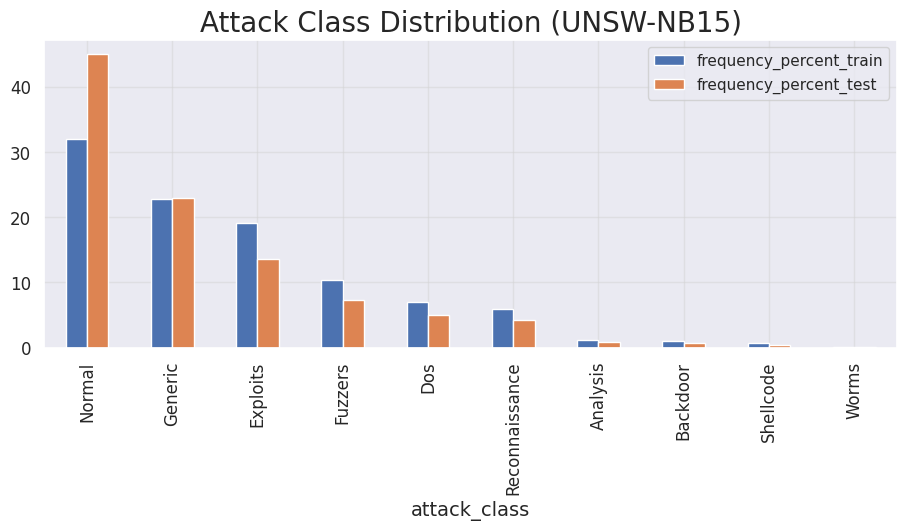

In [54]:
# Attack class bar plot
plot = attack_class_dist[['frequency_percent_train', 'frequency_percent_test']].plot(kind='bar');
plot.set_title('Attack Class Distribution (UNSW-NB15)', fontsize=20);
plot.grid(color='lightgray', alpha=0.5);


### Scaling Numerical Attributes

In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Extract numeric columns and scale to zero mean / unit variance
cols = df_train.select_dtypes(include=['float64', 'int64']).columns
sc_train = scaler.fit_transform(df_train.select_dtypes(include=['float64', 'int64']))
sc_test  = scaler.transform(df_test.select_dtypes(include=['float64', 'int64']))

sc_traindf = pd.DataFrame(sc_train, columns=cols)
sc_testdf  = pd.DataFrame(sc_test,  columns=cols)


### Encoding of Categorical Attributes

In [56]:
from sklearn.preprocessing import LabelEncoder

# Extract categorical columns
cattrain = df_train.select_dtypes(include=['object']).copy()
cattest  = df_test.select_dtypes(include=['object']).copy()

# Fit encoder on UNION of train+test values to avoid unseen-label errors
def safe_label_encode(train_col, test_col):
    le = LabelEncoder()
    le.fit(pd.concat([train_col, test_col], ignore_index=True))
    return le.transform(train_col), le.transform(test_col)

traincat_enc = cattrain.copy()
testcat_enc  = cattest.copy()
for col in cattrain.columns:
    traincat_enc[col], testcat_enc[col] = safe_label_encode(cattrain[col], cattest[col])

traincat = traincat_enc
testcat  = testcat_enc

# Separate target from encoded features
enctrain = traincat.drop(['attack_class'], axis=1)
enctest  = testcat.drop(['attack_class'], axis=1)

cat_Ytrain = traincat[['attack_class']].copy()
cat_Ytest  = testcat[['attack_class']].copy()


### Data Sampling

In [57]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Build combined feature matrix (scaled numeric + label-encoded categorical)
refclasscol = pd.concat(
    [pd.DataFrame(sc_train, columns=cols), enctrain.reset_index(drop=True)],
    axis=1
).columns
refclass = np.concatenate((sc_train, enctrain.values), axis=1)

# Reshape target to 1-D
y       = cat_Ytrain.values.reshape(-1,)
y_test  = cat_Ytest.values.reshape(-1,)

# Apply random over-sampling to balance minority classes
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(refclass, y)
print('Original dataset shape  {}'.format(Counter(y)))
print('Resampled dataset shape {}'.format(Counter(y_res)))


Original dataset shape  Counter({np.int64(6): 56000, np.int64(5): 40000, np.int64(3): 33393, np.int64(4): 18184, np.int64(2): 12264, np.int64(7): 10491, np.int64(0): 2000, np.int64(1): 1746, np.int64(8): 1133, np.int64(9): 130})
Resampled dataset shape Counter({np.int64(6): 56000, np.int64(5): 56000, np.int64(3): 56000, np.int64(4): 56000, np.int64(2): 56000, np.int64(7): 56000, np.int64(0): 56000, np.int64(1): 56000, np.int64(8): 56000, np.int64(9): 56000})


### Feature Selection

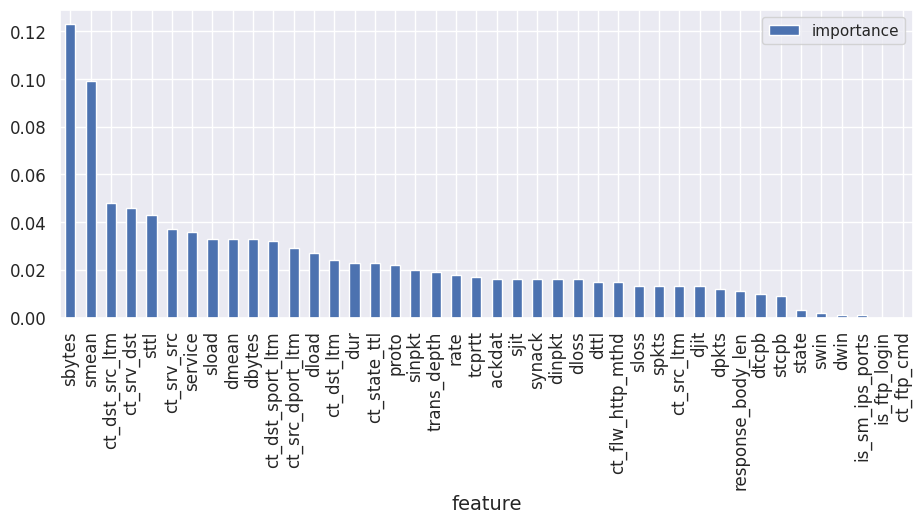

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

rfc = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# Impute any NaN values before fitting
imputer = SimpleImputer(strategy='mean')
X_res_imputed = imputer.fit_transform(X_res)

rfc.fit(X_res_imputed, y_res)

# Plot feature importances
score = np.round(rfc.feature_importances_, 3)
importances = pd.DataFrame({'feature': refclasscol, 'importance': score})
importances = importances.sort_values('importance', ascending=False).set_index('feature')

plt.rcParams['figure.figsize'] = (11, 4)
importances.plot.bar();


In [59]:
# Select top-10 features by Random Forest importance
feature_map_sorted = sorted(zip(rfc.feature_importances_, refclasscol), key=lambda x: x[0], reverse=True)
selected_features  = [v for (i, v) in feature_map_sorted[:10]]

print('Selected Features:')
for f in selected_features:
    print(' ', f)


Selected Features:
  sbytes
  smean
  ct_dst_src_ltm
  ct_srv_dst
  sttl
  ct_srv_src
  service
  dmean
  dbytes
  sload


### Dataset Partition

In [61]:
# Build resampled training dataframe
newcol = list(refclasscol) + ['attack_class']
new_y_res = y_res[:, np.newaxis]
res_arr   = np.concatenate((X_res, new_y_res), axis=1)
res_df    = pd.DataFrame(res_arr, columns=newcol)

# Build test dataframe (numeric + categorical, all as float64)
reftest = pd.concat([sc_testdf.reset_index(drop=True), testcat.reset_index(drop=True)], axis=1)
for col in testcat.columns:
    reftest[col] = reftest[col].astype(np.float64)

print('res_df shape :', res_df.shape)
print('reftest shape:', reftest.shape)


res_df shape : (560000, 43)
reftest shape: (82332, 43)


In [ ]:
reftest.head()


In [62]:
from collections import defaultdict
classdict = defaultdict(list)

# Recover the integer encoding for each attack class name
# (same encoding used when we called safe_label_encode on attack_class)
from sklearn.preprocessing import LabelEncoder as LE
_le = LE()
_le.fit(pd.concat([df_train['attack_class'] if 'attack_class' in df_train.columns
                    else pd.Series(dtype=str),
                    pd.Series(cattrain['attack_class'].values)], ignore_index=True)
         if False else  # use the already-encoded mapping below
         pd.concat([pd.Series(cattrain['attack_class'].values),
                    pd.Series(cattest['attack_class'].values)], ignore_index=True))

label_map = dict(zip(_le.classes_, _le.transform(_le.classes_).tolist()))
print('Label mapping:', label_map)

normal_val = float(label_map.get('Normal', -1))

# Build list of (attack_name, encoded_value) for every non-Normal class
attack_classes_encoded = [
    (name, float(val))
    for name, val in label_map.items()
    if name != 'Normal'
]
print('Normal value :', normal_val)
print('Attack classes:', attack_classes_encoded)


Label mapping: {'Analysis': 0, 'Backdoor': 1, 'Dos': 2, 'Exploits': 3, 'Fuzzers': 4, 'Generic': 5, 'Normal': 6, 'Reconnaissance': 7, 'Shellcode': 8, 'Worms': 9}
Normal value : 6.0
Attack classes: [('Analysis', 0.0), ('Backdoor', 1.0), ('Dos', 2.0), ('Exploits', 3.0), ('Fuzzers', 4.0), ('Generic', 5.0), ('Reconnaissance', 7.0), ('Shellcode', 8.0), ('Worms', 9.0)]


In [63]:
def create_classdict():
    '''Subdivide datasets into binary (Normal vs one attack type) subsets.'''
    for attack_name, attack_val in attack_classes_encoded:
        train_subset = res_df.loc[
            (res_df['attack_class'] == normal_val) | (res_df['attack_class'] == attack_val)
        ]
        test_subset = reftest.loc[
            (reftest['attack_class'] == normal_val) | (reftest['attack_class'] == attack_val)
        ]
        key = 'Normal_' + attack_name
        classdict[key].append(train_subset)
        classdict[key].append(test_subset)

create_classdict()
print('classdict keys:', list(classdict.keys()))


classdict keys: ['Normal_Analysis', 'Normal_Backdoor', 'Normal_Dos', 'Normal_Exploits', 'Normal_Fuzzers', 'Normal_Generic', 'Normal_Reconnaissance', 'Normal_Shellcode', 'Normal_Worms']


In [64]:
for k, v in classdict.items():
    print(k, '| train rows:', len(v[0]), '| test rows:', len(v[1]))


Normal_Analysis | train rows: 112000 | test rows: 37677
Normal_Backdoor | train rows: 112000 | test rows: 37583
Normal_Dos | train rows: 112000 | test rows: 41089
Normal_Exploits | train rows: 112000 | test rows: 48132
Normal_Fuzzers | train rows: 112000 | test rows: 43062
Normal_Generic | train rows: 112000 | test rows: 55871
Normal_Reconnaissance | train rows: 112000 | test rows: 40496
Normal_Shellcode | train rows: 112000 | test rows: 37378
Normal_Worms | train rows: 112000 | test rows: 37044


In [65]:
# Select the first available binary pair for model training
# Change `first_key` to any key from classdict to train on a different attack type
first_key = list(classdict.keys())[0]
pretrain  = classdict[first_key][0]
pretest   = classdict[first_key][1]
grpclass  = first_key
print('Selected pair:', grpclass)
print('Train size:', pretrain.shape, '| Test size:', pretest.shape)


Selected pair: Normal_Analysis
Train size: (112000, 43) | Test size: (37677, 43)


In [66]:
pretrain.head()


,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,proto,service,state,attack_class
0,0.212535,1.546539,3.800455,0.025778,3.712307,-0.575341,-1.443048,-0.457978,-0.389766,0.383148,0.243118,3.604053,-0.134507,-0.083027,-0.011723,0.647736,1.092456,-0.356217,-0.351753,1.103244,-0.514628,-0.474115,-0.500199,-0.384762,4.366068,-0.136415,-0.039557,0.158213,-1.366486,-0.148270,-0.420468,-0.554373,-0.340437,-0.11859,-0.11859,-0.189768,-0.355200,0.083597,-0.126508,113.0,0.0,4.0,6.0
3,0.384283,3.124480,7.609704,0.093355,7.517093,-0.574770,-1.443048,-0.457978,-0.389696,0.661315,0.500675,7.264011,-0.134946,-0.084815,-0.020530,0.569899,1.092456,1.352931,-0.227056,1.103244,-0.514628,-0.474023,-0.500298,-0.394533,4.458977,-0.136415,-0.039557,-0.028627,-1.366486,-0.396641,-0.420468,-0.554373,-0.249164,-0.11859,-0.11859,-0.189768,-0.595543,-0.009367,-0.126508,113.0,0.0,4.0,6.0
4,-0.209612,-0.133677,-0.153908,-0.049866,-0.102795,-0.559578,-1.443048,-0.457978,-0.387348,-0.022812,-0.075040,-0.131759,-0.136142,-0.089363,-0.110668,-0.148818,-0.915407,-0.715177,-0.715569,-0.906432,-0.521660,-0.484346,-0.503014,-0.350561,-0.167134,-0.136415,-0.039557,-0.589150,-1.366486,-0.272456,-0.544736,-0.554373,-0.705529,-0.11859,-0.11859,-0.189768,-0.475371,-0.567147,-0.126508,119.0,2.0,2.0,6.0
8,-0.204507,0.231587,0.208878,0.163918,-0.080394,-0.560348,-1.443048,-0.457978,-0.344223,0.042188,0.197667,0.019949,-0.136048,-0.088540,-0.109730,-0.148374,1.092456,2.250670,0.669322,1.103244,-0.513254,-0.471857,-0.499928,2.854492,-0.171005,-0.136415,-0.039557,-0.775991,-1.366486,-0.520827,-0.544736,-0.554373,-0.705529,-0.11859,-0.11859,-0.189768,-0.595543,-0.753074,-0.126508,113.0,9.0,4.0,6.0
9,-0.206267,0.202366,0.281435,-0.033684,0.126102,-0.551022,-1.443048,-0.457978,-0.384560,4.429466,0.031013,0.209585,-0.136077,-0.088912,-0.110091,-0.142266,1.092456,1.492206,1.512327,1.103244,-0.513065,-0.471466,-0.499977,-0.365219,2.078175,-0.136415,-0.039557,-0.308889,-1.366486,-0.520827,-0.544736,-0.554373,-0.522983,-0.11859,-0.11859,-0.189768,-0.595543,-0.381220,-0.126508,113.0,0.0,4.0,6.0


### Finalize data preprocessing for training

In [67]:
from sklearn.preprocessing import OneHotEncoder

Xresdf  = pretrain
newtest = pretest

# Identify categorical vs numeric among selected features
# (proto, service, state were label-encoded so they sit in refclasscol as numerics;
#  one-hot encoding is applied only if they appear by name in selected_features)
cat_cols_in_selected = [f for f in selected_features if f in ['proto', 'service', 'state']]
num_cols_in_selected = [f for f in selected_features if f not in cat_cols_in_selected]

Xresdfnew  = Xresdf[selected_features]
Xtest_feat = newtest[selected_features]

if cat_cols_in_selected:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    enc.fit(Xresdfnew[cat_cols_in_selected])
    X_train_1hotenc = enc.transform(Xresdfnew[cat_cols_in_selected])
    X_test_1hotenc  = enc.transform(Xtest_feat[cat_cols_in_selected])
    X_train = np.concatenate((Xresdfnew[num_cols_in_selected].values, X_train_1hotenc), axis=1)
    X_test  = np.concatenate((Xtest_feat[num_cols_in_selected].values, X_test_1hotenc), axis=1)
else:
    # All selected features are numeric — skip one-hot encoding
    X_train = Xresdfnew.values
    X_test  = Xtest_feat.values

Y_train = Xresdf[['attack_class']].values.reshape(-1,)
Y_test  = newtest[['attack_class']].values.reshape(-1,)

print('X_train:', X_train.shape, '| Y_train:', Y_train.shape)
print('X_test :', X_test.shape,  '| Y_test :', Y_test.shape)


X_train: (112000, 19) | Y_train: (112000,)
X_test : (37677, 19) | Y_test : (37677,)


## Train Models

In [68]:
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

# Train KNeighborsClassifier Model
KNN_Classifier = KNeighborsClassifier(n_jobs=-1)
KNN_Classifier.fit(X_train, Y_train);

# Train LogisticRegression Model
LGR_Classifier = LogisticRegression(n_jobs=-1, random_state=0)
LGR_Classifier.fit(X_train, Y_train);

# Train Gaussian Naive Baye Model
BNB_Classifier = BernoulliNB()
BNB_Classifier.fit(X_train, Y_train)

# Train Decision Tree Model
DTC_Classifier = tree.DecisionTreeClassifier(criterion='entropy', random_state=0)
DTC_Classifier.fit(X_train, Y_train);

# Train RandomForestClassifier Model
RF_Classifier = RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=0)
RF_Classifier.fit(X_train, Y_train);

# Train SVM Model
SVC_Classifier = SVC(random_state=0)
SVC_Classifier.fit(X_train, Y_train)

## Train Ensemble Model (This method combines all the individual models above except RandomForest)
#combined_model = [('Naive Baye Classifier', BNB_Classifier),
#                 ('Decision Tree Classifier', DTC_Classifier),
#                ('KNeighborsClassifier', KNN_Classifier),
#               ('LogisticRegression', LGR_Classifier)
#             ]
#VotingClassifier =  VotingClassifier(estimators = combined_model,voting = 'soft', n_jobs=-1)
#VotingClassifier.fit(X_train, Y_train);

SVC(random_state=0)

## Evaluate Models

In [69]:
from sklearn import metrics

models = []
models.append(('SVM Classifier', SVC_Classifier))
models.append(('Naive Baye Classifier', BNB_Classifier))
models.append(('Decision Tree Classifier', DTC_Classifier))
models.append(('RandomForest Classifier', RF_Classifier))
models.append(('KNeighbors Classifier', KNN_Classifier))
models.append(('Logistic Regression', LGR_Classifier))
#models.append(('VotingClassifier', VotingClassifier))
xx=['SVM','Naive Bayes','Decision Tree','Random Forest','Kneighbours','Logistic Regression']
yy=[]
yy2=[]
for i, v in models:
    scores = cross_val_score(v, X_train, Y_train, cv=10)
    accuracy = metrics.accuracy_score(Y_train, v.predict(X_train))
    confusion_matrix = metrics.confusion_matrix(Y_train, v.predict(X_train))
    classification = metrics.classification_report(Y_train, v.predict(X_train))
    print()
    print('============================== {} {} Model Evaluation =============================='.format(grpclass, i))
    print()
    print ("Cross Validation Mean Score:" "\n", scores.mean())
    print()
    print ("Model Accuracy:" "\n", accuracy)
    yy2.append(accuracy)
    yy.append(scores.mean())
    print()
    print("Confusion matrix:" "\n", confusion_matrix)
    print()
    print("Classification report:" "\n", classification)
    print()


============================== Normal_Analysis SVM Classifier Model Evaluation ==============================

Cross Validation Mean Score:
 0.9835625

Model Accuracy:
 0.9838303571428572

Confusion matrix:
 [[55791   209]
 [ 1602 54398]]

Classification report:
               precision    recall  f1-score   support

         0.0       0.97      1.00      0.98     56000
         6.0       1.00      0.97      0.98     56000

    accuracy                           0.98    112000
   macro avg       0.98      0.98      0.98    112000
weighted avg       0.98      0.98      0.98    112000



============================== Normal_Analysis Naive Baye Classifier Model Evaluation ==============================

Cross Validation Mean Score:
 0.7751607142857142

Model Accuracy:
 0.7751607142857143

Confusion matrix:
 [[39610 16390]
 [ 8792 47208]]

Classification report:
               precision    recall  f1-score   support

         0.0       0.82      0.71      0.76     56000
         6.0     

##Ploting Results

The best algorithm based on Accuracy Rate is Random Forest

Algorithm Performance Table:
          Algorithm Accuracy Rate (%)
                SVM            98.36%
        Naive Bayes            77.52%
      Decision Tree            99.76%
      Random Forest            99.78%
        Kneighbours            99.33%
Logistic Regression            94.44%


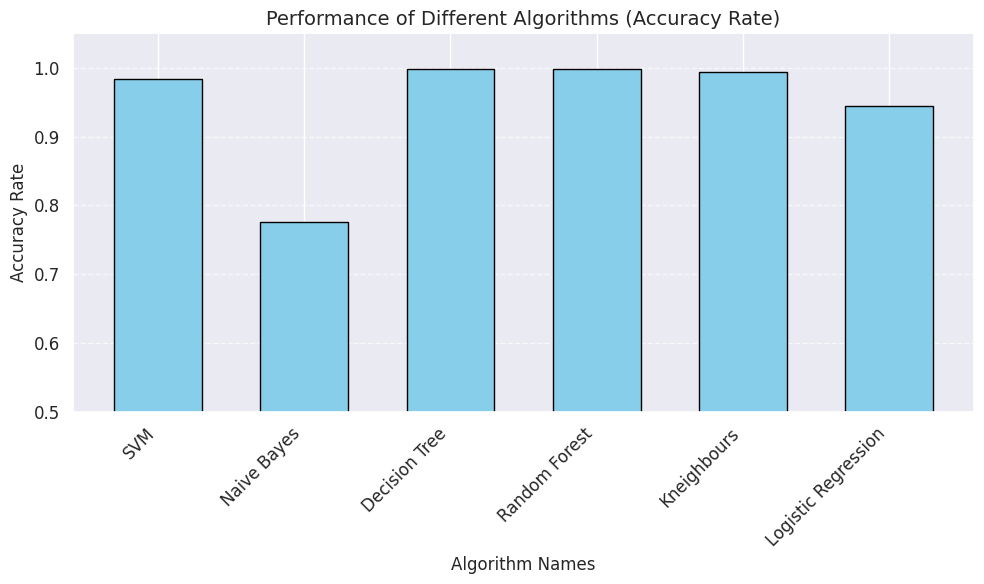

In [70]:
import pandas as pd

# Find the index of the maximum cross-validation score
best_algorithm_index = yy.index(max(yy))
best_algorithm_name = xx[best_algorithm_index]

# Create a list of colors for the bars, making all of them skyblue
colors = ['skyblue'] * len(xx)

# Plot the bars with adjusted width and gap
plt.figure(figsize=(10, 6))
bar_width = 0.6
x_indexes = np.arange(len(xx))
plt.bar(x_indexes, yy, width=bar_width, color=colors, edgecolor='black')

# Adjust the spacing between bars and y-axis limits
plt.xticks(x_indexes, xx, rotation=45, ha='right') # Rotate labels for better readability
plt.ylim(0.5, 1.05) # Start y-axis from 0.5 as requested, with a little buffer on top

# Adding labels and title
plt.xlabel('Algorithm Names', fontsize=12)
plt.ylabel('Accuracy Rate', fontsize=12)
plt.title('Performance of Different Algorithms (Accuracy Rate)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Print the best algorithm (still useful information)
print(f"The best algorithm based on Accuracy Rate is {best_algorithm_name}")

# Create and display the table of results (only cross-validation mean score)
results_df = pd.DataFrame({
    'Algorithm': xx,
    'Accuracy Rate (%)': [f'{score:.2%}' for score in yy]
})
print("\nAlgorithm Performance Table:")
print(results_df.to_string(index=False))

# Show the plot
plt.show()